# 2026 NASCAR Chase Track Performance Heatmap

### Comparing regular-season points scored by Chase drivers at tracks featured in the 2026 NASCAR Cup Series Chase
This project compares the regular-season performance of 2026 NASCAR Cup Series Chase drivers at tracks that will appear again during the Chase.

A heatmap is used to visualize the points scored by each driver at each track, making it easier to identify drivers and tracks with particularly strong or weak results.

## Imports

Import the libraries used for data manipulation and visualization.

In [10]:
# Library Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data / CSV Imports
df = pd.read_csv("cup_rr_ 2026_results.csv")

## Define Chase Drivers and Tracks

Define the 2026 Chase tracks that were also raced during the regular season and identify the 16 drivers in the Chase field.

The race results are then sorted chronologically and filtered to include only the selected drivers and tracks used in the heatmap analysis.

In [11]:
# List of Drivers and Tracks in the 2026 Chase

# Tracks in Chase (that were also run during the 2026 regular season)
chase_tracks = [
    "Darlington",
    "Bristol",
    "Kansas",
    "Las Vegas",
    "Charlotte",
    "Phoenix",
    "Talladega",
    "Martinsville"]

# Identify Chase drivers by total regular-season points
chase_drivers = df.groupby("Driver")["Pts"].sum().sort_values(ascending=False).head(16).index

# Order DF by race_number:
df = df.sort_values('race_number')

# Filter DF to chase_tracks
df = df[df['site'].isin(chase_tracks)]
df = df[df['Driver'].isin(chase_drivers)].copy()

# Inspect Shape of DF
df.shape  # (128,19) 8 Race Resutlts x 16 Drivers

(128, 19)

## Prepare Heatmap Data

Select the relevant driver, track, and points columns to reshaping to wide format.

Each driver becomes a row, each Chase track becomes a column, and the points scored in each race become the cell values.

The resulting table is then ordered by the 2026 Chase schedule and by the drivers' regular-season points ranking.

In [12]:
# View Three Pertinent Columns
# Driver | Site | Pts
print(f"DF Main Columns:\n\n{df[['Driver', 'site', 'Pts']]}\n\n\n")

# Pivot the table to wide Format - Index on the Driver
heatmap_df = df.pivot(
    index='Driver',
    columns='site',
    values='Pts')

# Sort columns by the sequential order of the 2026 Chase schedule
heatmap_df = heatmap_df[chase_tracks]

# Sort rows by driver regular-season points ranking
heatmap_df = heatmap_df.reindex(chase_drivers)

# View pivoted table DF (heatmap_df)
print(f"Pivoted Table:\n\n{heatmap_df}")

DF Main Columns:

               Driver       site   Pts
450     Chase Briscoe    Phoenix   1.0
433    Carson Hocevar    Phoenix  21.0
436     Chase Elliott    Phoenix  14.0
421     Tyler Reddick    Phoenix  39.0
420     William Byron    Phoenix  32.0
..                ...        ...   ...
77       Denny Hamlin  Charlotte  60.0
76   Christopher Bell  Charlotte  50.0
75      Daniel Suarez  Charlotte  55.0
97     Carson Hocevar  Charlotte  14.0
96      Bubba Wallace  Charlotte  15.0

[128 rows x 3 columns]



Pivoted Table:

site              Darlington  Bristol  Kansas  Las Vegas  Charlotte  Phoenix  \
Driver                                                                         
Denny Hamlin            26.0     41.0    52.0       70.0       60.0     47.0   
Ryan Blaney             42.0     53.0    13.0       23.0       41.0     65.0   
Tyler Reddick           70.0     33.0    71.0       30.0       53.0     39.0   
Ty Gibbs                33.0     59.0    38.0       39.0       53.0    

## Chase Track Points Heatmap

Visualize each driver's points scored at the eight Chase Tracks from 2026 regular season.

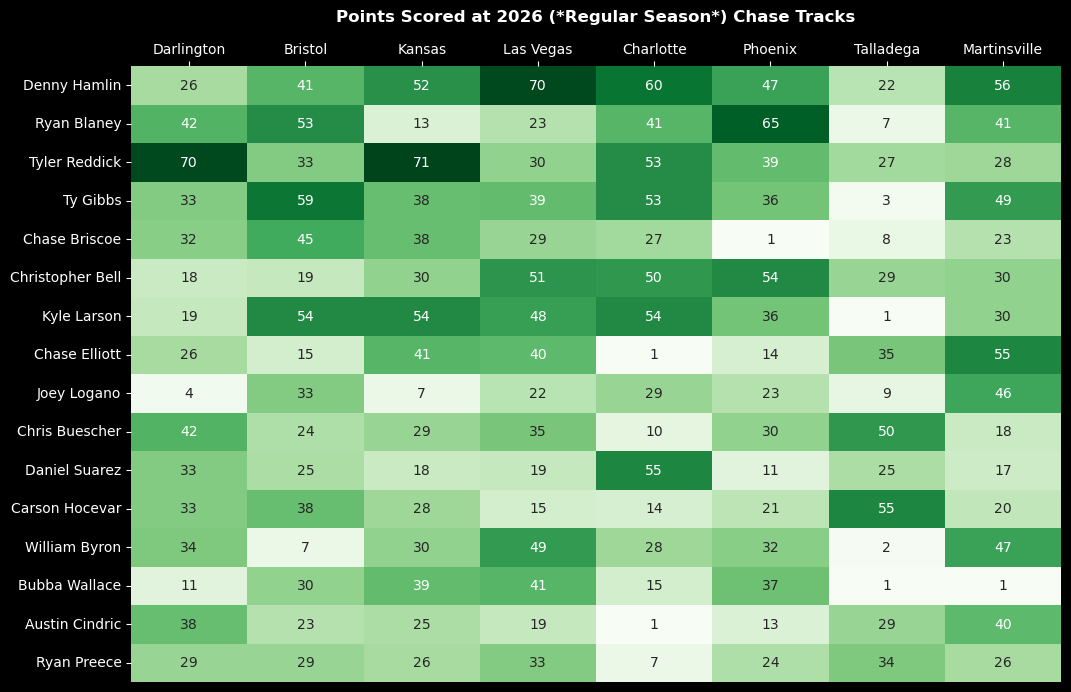

In [13]:
# Create heatmap
fig, ax = plt.subplots(figsize=(12, 8))

# Set dark background
fig.patch.set_facecolor("black")
ax.set_facecolor("black")

# Plot points by driver and track
sns.heatmap(
    heatmap_df,
    cmap="Greens",
    annot=True,
    fmt=".0f",
    cbar=False,
    linewidths=0.001,
    ax=ax)

# Move track names and axis label to top
ax.xaxis.tick_top()
ax.xaxis.set_label_position("top")

# Top axis label
ax.set_xlabel(
    "Points Scored at 2026 (*Regular Season*) Chase Tracks",
    fontsize=12,
    fontweight='bold',
    color="white", labelpad=15) # Label Location



# Remove y-axis label
ax.set_ylabel("")

# Format tick labels for dark background
ax.tick_params(axis="x", colors="white")
ax.tick_params(axis="y", colors="white")

plt.show()

## Total Points at Chase Tracks

Aggregate each driver's points across the eight Chase tracks ran in the regular season to compare overall performance.

The horizontal bar chart ranks drivers by total points scored at these tracks during the 2026 regular season. 

Bar colors are based on each driver's primary sponsor to provide additional visual distinction.

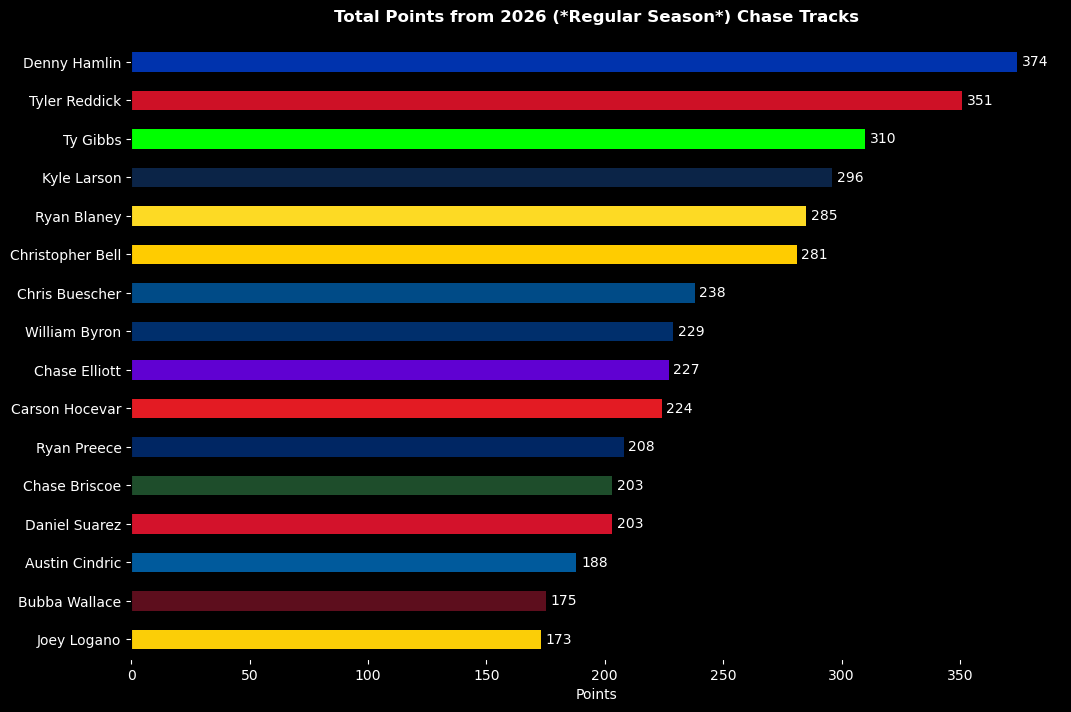

In [14]:
# Create Horizontal Barchart for Points at Chase Tracks

# Assign colors to drivers based on sponsor
sponsor_colors = {
    "Denny Hamlin": "#0033AD",
    "Ryan Blaney": "#FDDA24",
    "Ty Gibbs": "#00FF00",
    "Tyler Reddick": "#CE1126",
    "Christopher Bell": "#FFCC00",
    "Chase Briscoe": "#1E4D2B",
    "Kyle Larson": "#0B2447",
    "Chase Elliott": "#6001D2",
    "Joey Logano": "#FBCE07",
    "Chris Buescher": "#004B87",
    "Carson Hocevar": "#E31B23",
    "William Byron": "#002F6C",
    "Daniel Suarez": "#D3122B",
    "Bubba Wallace": "#5D0E1D",
    "Austin Cindric": "#005A9C",
    "Ryan Preece": "#002663"}


# Create series to plot (Points from Chase Tracks and Drivers in Chase)
chase_track_points = (df.groupby("Driver")["Pts"].sum().sort_values(ascending=False))


# Assign Colors to Drivers in the chart
bar_colors = [sponsor_colors[driver] for driver in chase_track_points.index]

# Plot Bargraph
fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor("black")
ax.set_facecolor("black")

# Horizontal bar chart
chase_track_points.plot(
    kind="barh",
    ax=ax,
    color=bar_colors)

# Highest total at the top
ax.invert_yaxis()

# Make labels white
ax.set_title(
    "Total Points from 2026 (*Regular Season*) Chase Tracks",
    color="white",
    fontsize=12,
    fontweight="bold",
    pad=15)

ax.tick_params(axis="x", colors="white")
ax.tick_params(axis="y", colors="white")

ax.set_xlabel("Points", color="white")
ax.set_ylabel("")

# Add point totals at end of bars
for i, value in enumerate(chase_track_points):
    ax.text(
        value + 2,
        i,
        f"{value:.0f}",
        va="center",
        color="white")

plt.show()